# Minimal DREGON + RPS Notebook

1. **Load DREGON** with the new `utils.data` time-series containers (`UniformSeries`, `EventSeries`, `TimeFrame`).
2. **Import RPS predictors** (`RotorEncoder`, `RPSPredictionHead`) from the model zoo.

## 1. Imports

In [38]:
import os
import sys
import numpy as np
import librosa as lr
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional

sys.path.insert(0, str(Path.cwd().parent))

# ---------- new data utils ----------
from utils.data import UniformSeries, EventSeries, TimeFrame

# ---------- DREGON loader ----------
from data_processing.dregon import (
    load_dregon_dataset,
    load_record_from_sample,
    get_geometry,
)

# ---------- RPS predictor models ----------
from models.rps_predictor import SimpleConv

# ---------- torch ----------
import torch

DATA_DIR = Path("../data")
print("imports OK")

imports OK


## 2. Helper: load a `TimeFrame` from an HF dataset sample

Wraps **every** time series in the `DREGONRecord` into the new container algebra, preserving original field names.

In [2]:
def load_timeframe_from_sample(sample, geometry=None):
    """
    Load a full DREGONRecord from an HF dataset sample and wrap every
    time series into `utils.data` containers.

    Returns
    -------
    rec : DREGONRecord
        The raw record (kept for metadata access).
    frame : TimeFrame
        Dict-like container with tracks:
        • `audio`                 → UniformSeries  (n_samples, n_channels)
        • `motors_measured`       → EventSeries    (n_events, 4)
        • `motors_command`        → EventSeries    (n_events, 4)
        • `imu_angular_velocity`  → EventSeries    (n_events, 3)
        • `imu_acceleration`      → EventSeries    (n_events, 3)
        • `source_position_azimuth`   → EventSeries  (n_events,)
        • `source_position_elevation` → EventSeries  (n_events,)
        • `source_position_distance`  → EventSeries  (n_events,)
    """
    rec = load_record_from_sample(sample, geometry=geometry)

    # audio timestamps define the global domain
    t_start = float(rec.audio_timestamps[0])
    t_end   = float(rec.audio_timestamps[-1]) + 1.0 / rec.sample_rate

    tracks = {}

    # ---- audio ----
    tracks["audio"] = UniformSeries.from_samples(
        samples=rec.audio,
        sr=rec.sample_rate,
        t_start=t_start,
    )

    # ---- motors ----
    if rec.motors is not None:
        tracks["motors_measured"] = EventSeries.from_events(
            timestamps=rec.motors.timestamps,
            values=rec.motors.measured,
        )
        tracks["motors_command"] = EventSeries.from_events(
            timestamps=rec.motors.timestamps,
            values=rec.motors.command,
        )

    # ---- IMU ----
    if rec.imu is not None:
        tracks["imu_angular_velocity"] = EventSeries.from_events(
            timestamps=rec.imu.timestamps,
            values=rec.imu.angular_velocity,
        )
        tracks["imu_acceleration"] = EventSeries.from_events(
            timestamps=rec.imu.timestamps,
            values=rec.imu.acceleration,
        )

    # ---- source position ----
    if rec.source_position is not None:
        tracks["source_position_azimuth"] = EventSeries.from_events(
            timestamps=rec.source_position.timestamps,
            values=rec.source_position.azimuth[:, None],  # keep 2-D shape
        )
        tracks["source_position_elevation"] = EventSeries.from_events(
            timestamps=rec.source_position.timestamps,
            values=rec.source_position.elevation[:, None],
        )
        tracks["source_position_distance"] = EventSeries.from_events(
            timestamps=rec.source_position.timestamps,
            values=rec.source_position.distance[:, None],
        )

    frame = TimeFrame.from_tracks(tracks)
    return rec, frame

## 3. Load DREGON (HuggingFace-style lazy dataset)

In [3]:
# Lazy metadata – no audio loaded yet
ds = load_dregon_dataset(DATA_DIR, splits=["in_flight_noise", "in_flight_source"])
print(ds)
print("Splits:", list(ds.keys()))
print("First sample keys:", list(ds["in_flight_noise"][0].keys()))

DatasetDict({
    in_flight_noise: Dataset({
        features: ['recording_id', 'split', 'flight_type', 'source_type', 'source_level', 'room', 'motor_id', 'motor_speed', 'audio_path', 'audiots_path', 'imu_path', 'motors_path', 'sourcepos_path', 'mic_positions_path', 'rotor_positions_path'],
        num_rows: 6
    })
    in_flight_source: Dataset({
        features: ['recording_id', 'split', 'flight_type', 'source_type', 'source_level', 'room', 'motor_id', 'motor_speed', 'audio_path', 'audiots_path', 'imu_path', 'motors_path', 'sourcepos_path', 'mic_positions_path', 'rotor_positions_path'],
        num_rows: 4
    })
})
Splits: ['in_flight_noise', 'in_flight_source']
First sample keys: ['recording_id', 'split', 'flight_type', 'source_type', 'source_level', 'room', 'motor_id', 'motor_speed', 'audio_path', 'audiots_path', 'imu_path', 'motors_path', 'sourcepos_path', 'mic_positions_path', 'rotor_positions_path']


## 4. Build a `TimeFrame` from the first sample

In [26]:
sample = ds["in_flight_noise"][0]
geometry = get_geometry(DATA_DIR / "DREGON")

rec, frame = load_timeframe_from_sample(sample, geometry=geometry)

print("Recording ID:", rec.recording_id)
print("Tracks:", list(frame.keys()))
print("Duration:", frame.duration, "s")
print("Audio shape:", frame["audio"].samples.shape)
for k in frame.keys():
    if k == "audio":
        continue
    series = frame[k]
    print(f"  {k}: {len(series)} events, values shape {series.values.shape if series.values is not None else None}")

frame = frame.shift(-frame.t_start)

Recording ID: free-flight_nosource_room1
Tracks: ['audio', 'motors_measured', 'motors_command', 'imu_angular_velocity', 'imu_acceleration']
Duration: 71.13145112991333 s
Audio shape: (3136897, 8)
  motors_measured: 59660 events, values shape (59660, 4)
  motors_command: 59660 events, values shape (59660, 4)
  imu_angular_velocity: 59660 events, values shape (59660, 3)
  imu_acceleration: 59660 events, values shape (59660, 3)


In [27]:
frame

TimeFrame(tracks={'audio': UniformSeries(sr=44100.0, t_first_edge=0.0, t_start=0.0, t_end=71.13145112991333), 'motors_measured': EventSeries(t_start=5.470263719558716, t_end=69.37379264831543), 'motors_command': EventSeries(t_start=5.470263719558716, t_end=69.37379264831543), 'imu_angular_velocity': EventSeries(t_start=5.467942714691162, t_end=69.37332582473755), 'imu_acceleration': EventSeries(t_start=5.467942714691162, t_end=69.37332582473755)}, t_start=0.0, t_end=71.13145112991333)

## 5. Slice / concat demo (new utils algebra)

In [28]:
t0 = frame.t_startt
t1 = t0 + 5.0          # 5-second chunk
t2 = t1 + 5.0

chunk_a = frame.slice(t0, t1)
chunk_b = frame.slice(t1, t2)
chunk_ab = chunk_a.concat(chunk_b)

# invariant: slice(a,b).concat(slice(b,c)) == slice(a,c)
assert chunk_ab.equal(frame.slice(t0, t2))
print("slice/concat invariant holds ✓")
print("chunk_a audio shape:", chunk_a["audio"].samples.shape)
print("chunk_b audio shape:", chunk_b["audio"].samples.shape)

slice/concat invariant holds ✓
chunk_a audio shape: (220500, 8)
chunk_b audio shape: (220500, 8)


## 6. Quick look at audio + motors

In [40]:
def plot_audio_and_rps(tf, prediction: Optional[np.ndarray] = None):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    
    # audio waveform (first channel)
    audio = tf["audio"]
    t_audio = np.arange(len(audio.samples)) / audio.sr + audio.t_start
    axes[0].plot(t_audio, audio.samples[:, 0])
    axes[0].set_ylabel("Audio (ch0)")
    axes[0].set_title(f"{rec.recording_id} | first 5 s")
    
    # motor RPS (measured)
    if "motors_measured" in tf:
        gt = tf["motors_measured"]
    elif "motor_command" in tf:
        gt = tf["motor_command"]
    else:
        gt = None

    if gt is not None:
        ls = '-' if prediction is None else '--'
        for rotor_i in range(gt.values.shape[1]):
            axes[1].plot(gt.timestamps + gt.t_start, gt.values[:, rotor_i], label=f"GT (R{rotor_i})", ls=ls)
        axes[1].set_ylabel("RPS (Hz)")
        axes[1].set_xlabel("Time (s)")
        axes[1].legend()

    if prediction is not None:
        for rotor_i in range(predictions.values.shape[1]):
            axes[1].plot(predictions.timestamps + predictions.t_start, predictions.values[:, rotor_i], label=f"Pred (R{rotor_i})", ls=ls)
    
    plt.tight_layout()
    plt.show()

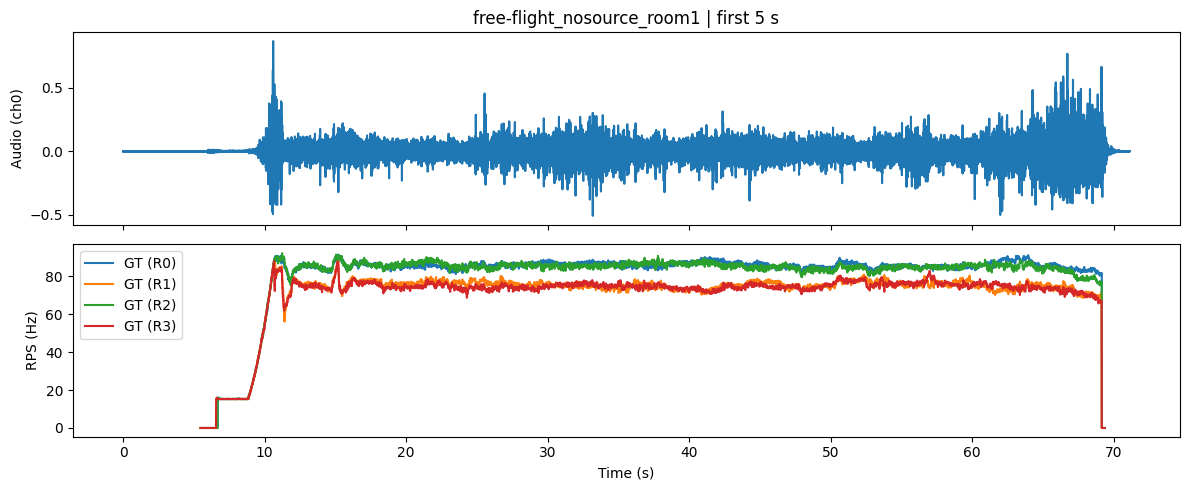

In [41]:
plot_audio_and_rps(frame)

## 7. Import & inspect RPS predictor models

In [42]:
model = SimpleConv()
state_dict = torch.load('../results/rps_exp_simple_conv/best_simple_conv.pt', map_location='cpu')
model.load_state_dict(state_dict)

<All keys matched successfully>

## 8. Evaluate